# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


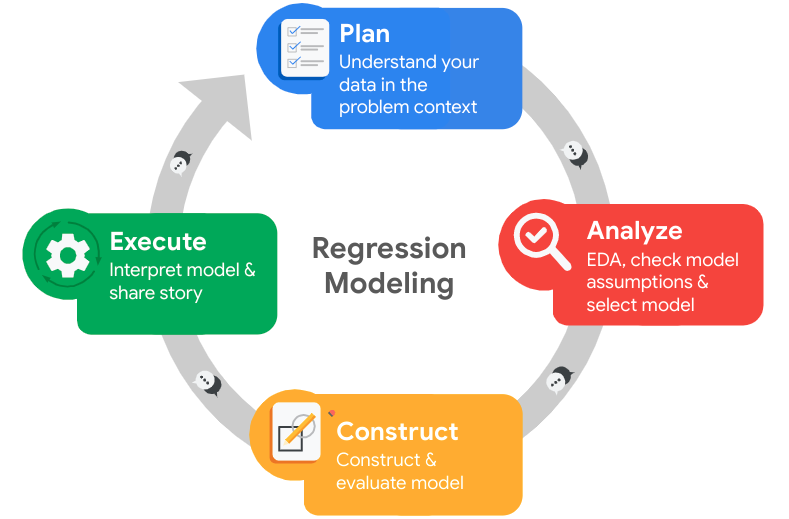

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [89]:
# Data manipulation packages
import pandas as pd
import numpy as np
# Visualization packages
import matplotlib.pyplot as plt
import seaborn as sns
# Hypothesis testing packages
from scipy import stats
# Data modeling packages
# Import packages for data modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, \
f1_score, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import plot_importance

### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [90]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe
df0 = pd.read_csv("HR_capstone_dataset.csv")

# Display first few rows of the dataframe
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [91]:
# Gather basic information about the data
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [92]:
# Gather descriptive statistics about the data
df0.describe(include = 'all')

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999,14999
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140,7316
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,NaN,NaN
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [93]:
# Display all column names
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [94]:
# Rename columns as needed
df0.rename(columns = {'average_montly_hours': 'average_monthly_hours', 'time_spend_company': 'time_at_company', 'Work_accident': 'work_accident', 'promotion_last_5years': 'promotion_last_5_years', 'Department': 'department'}, inplace = True)

# Display all column names after the update
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'time_at_company', 'work_accident', 'left',
       'promotion_last_5_years', 'department', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [95]:
# Check for missing values
df0.isna().sum()

satisfaction_level        0
last_evaluation           0
number_project            0
average_monthly_hours     0
time_at_company           0
work_accident             0
left                      0
promotion_last_5_years    0
department                0
salary                    0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [96]:
# Check for duplicates
df0.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
14994     True
14995     True
14996     True
14997     True
14998     True
Length: 14999, dtype: bool

In [97]:
# Inspect some rows containing duplicates as needed
df0[df0.duplicated()]

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_at_company,work_accident,left,promotion_last_5_years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [98]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df0.drop_duplicates(inplace=True)

# Display first few rows of new dataframe as needed
df0.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_at_company,work_accident,left,promotion_last_5_years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [99]:
df0.shape

(11991, 10)

### Check outliers

Check for outliers in the data.

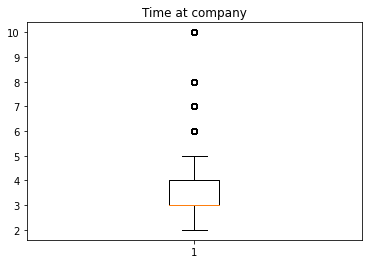

In [100]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers
plt.boxplot(df0['time_at_company'])
plt.title("Time at company")
plt.show()

In [101]:
# Determine the number of rows containing outliers
iqr = df0['time_at_company'].quantile(0.75) - df0['time_at_company'].quantile(0.25)
upper_outlier = df0['time_at_company'].quantile(0.75) + 1.5 * iqr
lower_outlier = df0['time_at_company'].quantile(0.25) - 1.5 * iqr
print("Number of rows with time at company as outlier:", df0[(df0['time_at_company'] > upper_outlier) | (df0['time_at_company'] < lower_outlier)].shape[0])

Number of rows with time at company as outlier: 824


Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [102]:
# Get numbers of people who left vs. stayed
print(df0['left'].value_counts())

# Get percentages of people who left vs. stayed
df0['left'].value_counts(normalize = True) * 100

0    10000
1     1991
Name: left, dtype: int64


0    83.39588
1    16.60412
Name: left, dtype: float64

### Data visualizations & Insights

Now, examine variables that you're interested in by creating plots and drawing insights to visualize relationships between variables in the data.

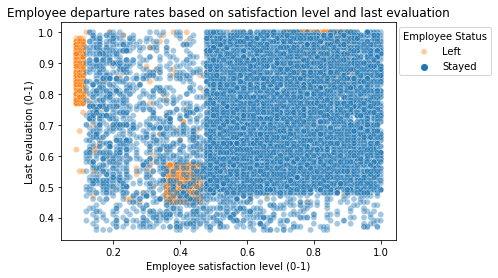

In [103]:
# Create a plot as needed
ax = sns.scatterplot(data = df0, x = 'satisfaction_level', y = 'last_evaluation', hue = 'left', alpha = 0.4)
ax.set_xlabel("Employee satisfaction level (0-1)")
ax.set_ylabel("Last evaluation (0-1)")
ax.legend(bbox_to_anchor = [1.3, 1], loc='upper right', labels = ['Left', 'Stayed'], title = 'Employee Status')
ax.set_title("Employee departure rates based on satisfaction level and last evaluation")
plt.show()

* There are 3 main patterns of employee attrition: A tight band on the far left edge with high evaluation but very low satisfaction of burnt-out employees, a large cluster in the lower-middle with below average evaluation and low satisfaction level, indicating disengagement in employees with substandard productivity, and a small group in the upper right corner of employees with very high evaluation and high satisfaction, who might choose other companies with better work offers. Thus, an effective retention program should address all 3 attrition trends.

* Specifically, the dense group of high performers with very low satisfaction levels are often the most expensive departures, suggesting workload problems combined with a lack of incentives and recognition for high productivity.


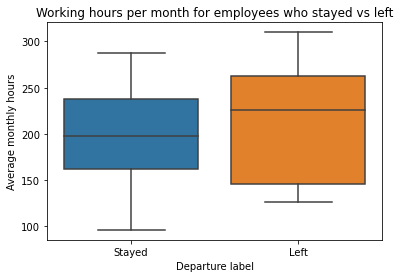

In [104]:
# Create a plot as needed
ax = sns.boxplot(data = df0, x = 'left', y = 'average_monthly_hours')
ax.set_xticklabels(['Stayed', 'Left'])
plt.xlabel("Departure label")
plt.ylabel("Average monthly hours")
plt.title("Working hours per month for employees who stayed vs left")
plt.show()

* Employees who left worked more hours on average than those who stayed (median 225 vs 200), and the upper whisker extends meaningfully higher (310 vs 285), confirming that elevated workload is a real signal in driving employee departure.
* The far more striking pattern is the dispersion gap: the leavers' IQR (145–265) is nearly twice as wide as the stayers' IQR (160–240), meaning leavers are drawn from a much more heterogeneous workload population rather than a single overworked cluster.

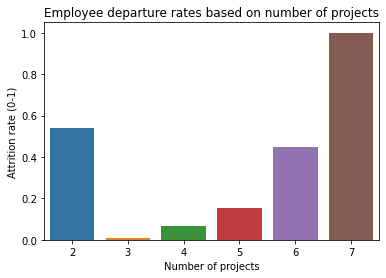

In [105]:
# Create a plot as needed
sns.barplot(data = df0.groupby('number_project', as_index = False)['left'].mean(), x = 'number_project', y = 'left')
plt.xlabel("Number of projects")
plt.ylabel("Attrition rate (0-1)")
plt.title("Employee departure rates based on number of projects")
plt.show()

* The relationship between number_project and attrition is strongly U-shaped, with elevated attrition at both extremes (2 projects and 7 projects) and the lowest attrition in the middle (3–4 projects). This points to a story about two distinct attrition modes - underutilization at the low end and overload at the high end - which aligns with the bimodality we observed in the hours_per_project violin plot earlier.
* The 7-project group shows a near 100% attrition, which serves as a simple rule-based flag (number_project = 7) to warn the HR team about an employee leaving the company.

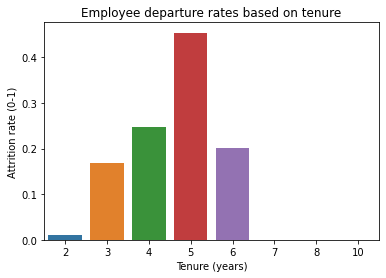

In [106]:
# Create a plot as needed
sns.barplot(data = df0.groupby('time_at_company', as_index = False)['left'].mean(), x = 'time_at_company', y = 'left')
plt.xlabel("Tenure (years)")
plt.ylabel("Attrition rate (0-1)")
plt.title("Employee departure rates based on tenure")
plt.show()

* Attrition occured primarily in employees with 3 to 6 years in tenure, with an alarming spike of 45 percent attrition for employees in their 5th year. This implies significant structural issues such as promotional timelines and vesting cliffs at the 3-5 year tenure mark, causing sharp rises in departure rates until the 7-year mark. Thus, retention programs that are effective at retaining people in their 3rd to 6th year at Salifort Motors will create more long-standing employees, reducing both recruiting and training costs for new employees.

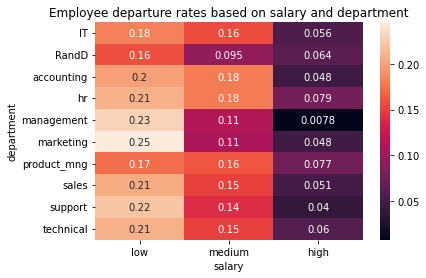

In [107]:
# Create a plot as needed
data = df0.groupby(['department', 'salary'])['left'].mean().unstack()
sns.heatmap(data[['low', 'medium', 'high']], annot = True)
plt.title("Employee departure rates based on salary and department")
plt.show()

* This heatmap suggests that salary tiers have a much bigger influence on employees' departure than their departments. While the "high" salary column is entirely dark with attrition rates from 0.8% to 7.9% and the "medium" column exhibits moderate rates of departure from 9.5% to 18%, the "low" column is uniformly bright with alarming rates from 16% to 25%. The attrition rate variation by salary is much more pronounced than the variation across departments, in which no clear department emerges with a higher attrition rate than other departments in each salary category.

* Moreover, marketing and management departments have the highest attrition rates of 25% and 23% in the low salary tier, while in the medium salary tier, their attrition rates dropped to just 11%, which is the second lowest among all departments, suggesting internal problems within both departments that sparked resignation among low-salary employees. Therefore, employees in these 2 departments and others such as sales, support, and technical would be more inspired to stay at the company given salary increments.

In [127]:
custom_colors = ["#ADD8E6", "#FF9999"]

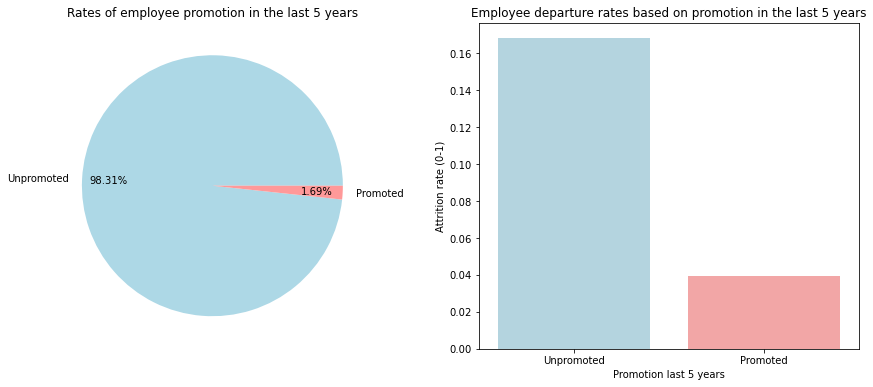

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
promotion_labels = ['Unpromoted', 'Promoted']

axes[0].pie(df0['promotion_last_5_years'].value_counts(normalize = True), labels = promotion_labels, autopct='%1.2f%%', pctdistance = 0.8, colors = custom_colors)
axes[0].set_title('Rates of employee promotion in the last 5 years')

data = df0.groupby(['promotion_last_5_years'], as_index = False)['left'].mean()
axes[1] = sns.barplot(data = data, x = 'promotion_last_5_years', y = 'left', palette = custom_colors)
axes[1].set_xticklabels(promotion_labels)
axes[1].set_xlabel('Promotion last 5 years')
axes[1].set_ylabel('Attrition rate (0-1)')
axes[1].set_title('Employee departure rates based on promotion in the last 5 years')

plt.show()

* Over the last 5 years, career advancement has been heavily stagnated, with a staggering 98.31% of the workforce remaining unpromoted. This severe lack of upward mobility serves as a primary root cause for widespread employee resignation and dissatisfaction.

* Consequently, this stagnation translates directly into a critical retention issue, as unpromoted employees resign at a rate (roughly 17%) more than four times higher than their promoted peers. To curb this costly turnover, the organization must immediately implement transparent career advancement pathways and more accessible promotion cycles.

## Step 3. Hypothesis testing 

Perform an A/B test to examine the difference in the means of a variable from 2 different categories.

* Null hypothesis: There is no difference in monthly workload between employees who stayed and left.
* Alternate hypothesis: There is a difference in monthly workload between employees who stayed and left.
* p-value threshold for significance: 0.05

In [21]:
stayed, left = df0[df0['left'] == 0], df0[df0['left'] == 1]
sampled_stayed = stayed.sample(n = 50, replace = True, random_state = 7011)
sampled_left = left.sample(n = 50, replace = True, random_state = 2167)

In [22]:
print(f"Monthly hours on average (stayed): {sampled_stayed['average_monthly_hours'].mean():.2f}")
print(f"Monthly hours on average (left): {sampled_left['average_monthly_hours'].mean():.2f}")
t_stat, p_value = stats.ttest_ind(a = sampled_stayed['average_monthly_hours'], b = sampled_left['average_monthly_hours'], equal_var = False)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

Monthly hours on average (stayed): 193.38
Monthly hours on average (left): 209.98
t-statistic: -1.5220
p-value: 0.1315


* Because the p-value is 0.1741 > 0.05, we fail to reject the null hypothesis.
* This, however, tells us an important reality: average workload is simply indifferentiable between leavers and stayers. The 16.6-hour difference in means appears significant but small relative to the within-group standard deviation, and the leaver distribution's much wider IQR (~145–265 vs ~160–240 for stayers) inflates the pooled standard error and pulls the t-statistic toward zero.
* Perhaps a statistic test about dispersion or shape would be better at verifying the difference in variance and the upper 50% range of average monthly hours between employees who stayed at left.

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


As previous analysis shows that most numerical attributes for leaving employee follow a bimodal distribution of high workload/ high production employees on one end and low workload/ low production employees on the other end, which violates the normality of features in the dataset, we will instead use a random forest model and an XGBoost model for supervised learning.


**Modeling workflow and model selection process**

Prior EDA has revealed that there are ~15000 videos in the dataset. This is sufficient to conduct a rigorous model validation workflow, broken into the following steps:

1. Split the data into train/validation/test sets (60/20/20)
2. Fit models and tune hyperparameters on the training set
3. Perform final model selection on the validation set
4. Assess the champion model's performance on the test set

In [23]:
# Convert categorical features into numerical with one-hot encoding (department) and ordinal encoding (salary) for feature dataset X
df0['salary'] = df0['salary'].replace({'low': 0, 'medium': 1, 'high': 2})
X = pd.get_dummies(df0.drop(columns = 'left'))
X.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_at_company,work_accident,promotion_last_5_years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,0,0,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,0,1,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,0,1,0,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,0,0,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,0,0,0,0,0,0,0,0,0,1,0,0


In [24]:
# Create target variable y
y = pd.get_dummies(df0['left'], drop_first = True)
y.rename(columns = {1.0: 'left'}, inplace = True)

**Create train/validation/test sets (60/20/20)**

In [25]:
# Split the data into training and testing sets (80/20 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 5044)

In [26]:
# Split the training data into train and validation sets (75/25 ratio)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size = 0.25, random_state = 1389)

In [27]:
# Get shape of each training, validation, and testing set
print(X_tr.shape, X_val.shape, X_test.shape) 
print(y_tr.shape, y_val.shape, y_test.shape)

(7194, 18) (2398, 18) (2399, 18)
(7194, 1) (2398, 1) (2399, 1)


## Step 4. Model Building, Step 5. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Modeling

Add as many cells as you need to conduct the modeling process.

### **Build a Random Forest classifier**

In [31]:
# Instantiate the random forest classifier
rf = RandomForestClassifier(class_weight='balanced', random_state = 9081)
# Create a dictionary of hyperparameters to tune
cv_params = {'n_estimators' : [25, 50, 100], 
              'max_depth' : [10, None],        
              'min_samples_leaf' : [1, 2, 5],
              'max_features' : ['sqrt', 0.5, 1.0], 
              'max_samples' : [0.5, 1.0]}
# Define a list of scoring metrics to capture
metrics = ('accuracy', 'precision', 'recall', 'f1', 'average_precision')
# Instantiate the GridSearchCV object
rf_val = GridSearchCV(rf, cv_params, scoring = metrics, refit = 'f1', n_jobs = -1)

In [32]:
%%time
### Fit the model to the data 
rf_val.fit(X_tr, y_tr)

CPU times: user 2.44 s, sys: 567 ms, total: 3 s
Wall time: 1min 8s


GridSearchCV(cv=None, error_score=nan,
             estimator=RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                              class_weight='balanced',
                                              criterion='gini', max_depth=None,
                                              max_features='auto',
                                              max_leaf_nodes=None,
                                              max_samples=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              n_estimators=100, n_j...
                                              random_state=9081, verbose=0,
                                   

In [33]:
#Examine the best recall score
rf_val.best_score_

0.9471877592513156

In [34]:
# Examine best parameters
rf_val.best_params_

{'max_depth': None,
 'max_features': 0.5,
 'max_samples': 0.5,
 'min_samples_leaf': 1,
 'n_estimators': 25}

In [35]:
# Access the GridSearch results and convert it to a pandas df
rf_results_df = pd.DataFrame(rf_val.cv_results_)
# Examine the GridSearch results df at column `mean_test_precision` in the best index
rf_results_df['mean_test_precision'][rf_val.best_index_]

0.9900721242212068

### Evaluate Random Forest on validation data

In [65]:
target_labels = ['stayed', 'left']

In [80]:
y_pred = rf_val.best_estimator_.predict(X_val)
y_pred

array([0, 0, 0, ..., 0, 0, 1], dtype=uint8)

In [67]:
y_val

,left
10342,0
10463,0
10905,0
550,1
3882,0
...,...
3437,0
9875,0
4210,0
8815,0


Create a confusion matrix to visualize the results of the classification model

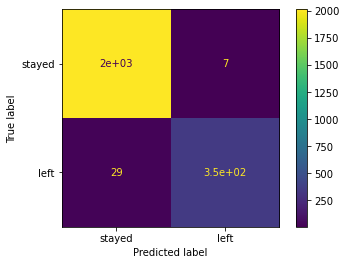

In [81]:
# Compute values for confusion matrix
rf_cm = confusion_matrix(y_val, y_pred)
# Create display of confusion matrix using ConfusionMatrixDisplay()
rf_disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=target_labels)
# Plot confusion matrix
rf_disp.plot()
# Display plot
plt.show()

In [83]:
# Display accuracy, precision, recall, F1, and PR AUC score
print(f"Random Forest accuracy score: {accuracy_score(y_val, y_pred):.4f}")
print(f"Random Forest precision score: {precision_score(y_val, y_pred):.4f}")
print(f"Random Forest recall score: {recall_score(y_val, y_pred):.4f}")
print(f"Random Forest F1 score: {f1_score(y_val, y_pred):.4f}")
print(f"Random Forest PR AUC (Average Precision): {average_precision_score(y_val, y_pred):.4f}")

Random Forest accuracy score: 0.9850
Random Forest precision score: 0.9804
Random Forest recall score: 0.9235
Random Forest F1 score: 0.9511
Random Forest PR AUC (Average Precision): 0.9175


In [69]:
# Create classification report for random forest model
print(classification_report(y_val, y_pred, target_names=target_labels))

              precision    recall  f1-score   support

      stayed       0.99      1.00      0.99      2019
        left       0.98      0.92      0.95       379

    accuracy                           0.98      2398
   macro avg       0.98      0.96      0.97      2398
weighted avg       0.98      0.98      0.98      2398



Create an AUC-PR curve to focus on the performance of leaver class

In [42]:
# Extract values to plot the curve
precision, recall, thresholds = precision_recall_curve(y_val, y_pred)

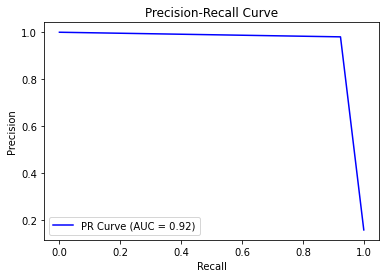

In [43]:
# Plot the Precision-Recall curve
plt.figure()
plt.plot(recall, precision, color='b', label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

### **Build an XGBoost model**

In [47]:
# Instantiate the XGBoost classifier
xgb = XGBClassifier(scale_pos_weight = 1/y['left'].mean() - 1, random_state = 2509)
# Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [5, 7],
               'learning_rate': [0.1, 0.3],
               'n_estimators': [50, 100, 250],
               'subsample': [0.5, 0.75, 1.0],
               'colsample_bytree': [0.5, 1.0],
               'min_child_weight': [1, 3, 5]
            }
# Define a list of scoring metrics to capture
metrics = ('accuracy', 'precision', 'recall', 'f1')
# Instantiatiate the GridSearchCV object
xgb_val = GridSearchCV(xgb, cv_params, scoring = metrics, refit = 'f1', n_jobs = -1)

In [48]:
%%time
# Fit the model to the data
xgb_val.fit(X_tr, y_tr)

CPU times: user 48.3 s, sys: 687 ms, total: 49 s
Wall time: 11min 52s


GridSearchCV(cv=None, error_score=nan,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     gamma=None, gpu_id=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     predictor=None, random_state=2509,
                                     reg_alpha=None, ...),
             iid='deprecated', n_jobs=-1,
             param_grid={'colsample_bytree': [0.5, 1.0],
                         'learning_rate': [0.1, 0.3], 

In [50]:
# Examine best recall score
xgb_val.best_score_

0.9381878977590089

In [51]:
# Examine best parameters
xgb_val.best_params_

{'colsample_bytree': 1.0,
 'learning_rate': 0.1,
 'max_depth': 7,
 'min_child_weight': 1,
 'n_estimators': 50,
 'subsample': 1.0}

In [52]:
# Access the GridSearch results and convert it to a pandas df
xgb_results_df = pd.DataFrame(xgb_val.cv_results_)
# Examine the GridSearch results df at column `mean_test_precision` in the best index
xgb_results_df['mean_test_precision'][xgb_val.best_index_]

0.9588181636012493

### Evaluate XGBoost on validation data

In [73]:
y_pred = xgb_val.best_estimator_.predict(X_val)
y_pred

array([0, 0, 0, ..., 0, 0, 1])

Create a confusion matrix to visualize the results of the classification model

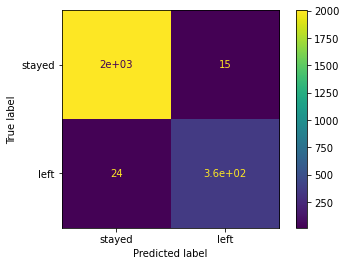

In [74]:
# Compute values for confusion matrix
xgb_cm = confusion_matrix(y_val, y_pred)
# Create display of confusion matrix using ConfusionMatrixDisplay()
xgb_disp = ConfusionMatrixDisplay(confusion_matrix=xgb_cm, display_labels=target_labels)
# Plot confusion matrix
xgb_disp.plot()
# Display plot
plt.show()

In [79]:
# Display accuracy, precision, recall, F1, and PR AUC score
print(f"XGBoost accuracy score: {accuracy_score(y_val, y_pred):.4f}")
print(f"XGBoost precision score: {precision_score(y_val, y_pred):.4f}")
print(f"XGBoost recall score: {recall_score(y_val, y_pred):.4f}")
print(f"XGBoost F1 score: {f1_score(y_val, y_pred):.4f}")
print(f"XGBoost PR AUC (Average Precision): {pr_auc:.4f}")

XGBoost accuracy score: 0.9837
XGBoost precision score: 0.9595
XGBoost recall score: 0.9367
XGBoost F1 score: 0.9479
XGBoost PR AUC (Average Precision): 0.9087


In [75]:
# Create a classification report
print(classification_report(y_val, y_pred, target_names=target_labels))

              precision    recall  f1-score   support

      stayed       0.99      0.99      0.99      2019
        left       0.96      0.94      0.95       379

    accuracy                           0.98      2398
   macro avg       0.97      0.96      0.97      2398
weighted avg       0.98      0.98      0.98      2398



In [77]:
# Extract values to plot the curve
precision, recall, thresholds = precision_recall_curve(y_val, y_pred)

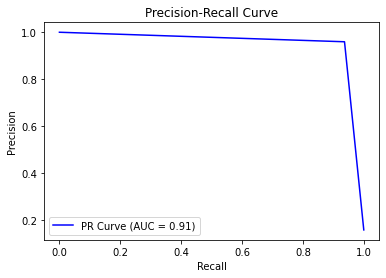

In [78]:
# Plot the Precision-Recall curve
plt.figure()
plt.plot(recall, precision, color='b', label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

Because the Random Forest model defeats the XGBoost model in F1 score and AUC-PR score, it is the champion model and will be used for predicting on the test data.

# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



In [84]:
y_pred = rf_val.best_estimator_.predict(X_test)

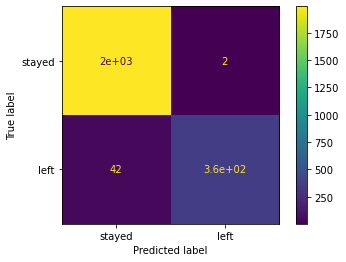

In [85]:
# Create a confusion matrix to visualize the results of the classification model

# Compute values for confusion matrix
rf_cm = confusion_matrix(y_test, y_pred)
# Create display of confusion matrix using ConfusionMatrixDisplay()
rf_disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=target_labels)
# Plot confusion matrix
rf_disp.plot()
# Display plot
plt.show()

### Evaluate model performance using metrics

In [86]:
# Display accuracy, precision, recall, F1, and PR AUC score
print(f"Random Forest accuracy score: {accuracy_score(y_test, y_pred):.4f}")
print(f"Random Forest precision score: {precision_score(y_test, y_pred):.4f}")
print(f"Random Forest recall score: {recall_score(y_test, y_pred):.4f}")
print(f"Random Forest F1 score: {f1_score(y_test, y_pred):.4f}")
print(f"Random Forest PR AUC (Average Precision): {average_precision_score(y_test, y_pred):.4f}")

Random Forest accuracy score: 0.9817
Random Forest precision score: 0.9945
Random Forest recall score: 0.8966
Random Forest F1 score: 0.9430
Random Forest PR AUC (Average Precision): 0.9092


In [87]:
print(classification_report(y_test, y_pred, target_names=target_labels))

              precision    recall  f1-score   support

      stayed       0.98      1.00      0.99      1993
        left       0.99      0.90      0.94       406

    accuracy                           0.98      2399
   macro avg       0.99      0.95      0.97      2399
weighted avg       0.98      0.98      0.98      2399



### **Feature importances of the champion model**

In [88]:
rf_val.best_estimator_.feature_importances_

array([0.39629671, 0.12006886, 0.08168951, 0.11251106, 0.25666024,
       0.00256292, 0.00108273, 0.00628783, 0.00128149, 0.0029278 ,
       0.00136457, 0.00199531, 0.00181115, 0.0018265 , 0.00043822,
       0.00370442, 0.00322727, 0.0042634 ])

In [62]:
print(X.columns)

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'time_at_company', 'work_accident',
       'promotion_last_5_years', 'salary', 'department_IT', 'department_RandD',
       'department_accounting', 'department_hr', 'department_management',
       'department_marketing', 'department_product_mng', 'department_sales',
       'department_support', 'department_technical'],
      dtype='object')


## Step 6. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results & model interpretation

-	The Random Forest model generalized well as test performance essentially matches validation. Test set scores (accuracy 0.98, precision 0.99, recall 0.90, F1 0.94, AUC-PR 0.91) are within a hair of the validation numbers, which is the ideal diagnostic. This means the 60/20/20 workflow was suitable for training the model.
-	Satisfaction is the single dominant driver, at 40% of total importance. This aligns with the satisfaction-evaluation scatter plot the EDA showed, as the majority of employees that resigned reported low to very low work satisfaction. Meanwhile, evaluation only contributes 12% of total importance, which correlates with the 2 primary groups of leavers, one with high performance and the other with low performance.
-	Tenure is the second strongest predictor at 26%, validating the year-5 cliff, which the model probably has learned to weigh heavily, which means the tree splits will likely concentrate around this cliff.
-	Workload features (number_project & average_monthly_hours) combine for 19.5% of the model’s predictive basis, despite the t-test showing insignificant differences in workload averages from stayers and leavers. This suggests that there might be a bimodal trend in leavers that the distribution mean could not capture, a group of people with average hours and overworked people with around 250 hours or more.
-	Promotion importance is only reported at 0.11%, which is surprising given the findings from the EDA. Perhaps the ratio of 1.69% of promoted people is such a small split that the model struggles to find the significance behind this feature.
-	Salary importance is only 0.63%, while the department features collectively contribute under 3%, which can come as a disparity from the salary dominance in the salary-department heatmap. Similar to promotion, salary is not appreciated by the model due to the relatively low rates of departure in each box (from 1% in high salary positions to 23% in low salary positions). Nevertheless, this doesn’t validate any of these 2 features, they just don’t exhibit high correlation with departure according to the model. Thus, both attributes should mainly be considered as strategic insights.
-	Overall, the feature importances partially correlate with observations from the EDA, while the final results can be considered impressive for an attrition prediction model, with 90% recall score and 91% AUC-PR score. 


### Conclusion, Recommendations, Next Steps

#### **Conclusion** *(specified for HR and managers)*

- EDA shows major problems in the company's promotion ladder with the 1.69% promotion rate, causing 45% of the company's employees to leave in year 5. In addition, low-salary workers are much more likely to leave the company than their coworkers in medium to high salary tiers.
- The satisfaction × evaluation scatter reveals the three clusters of leavers: burnt-out high performers (low satisfaction, high evaluation), disengaged (low satisfaction, low evaluation), and poached stars (high satisfaction, high evaluation); each of them requires a different manager action. The model's most predictive feature is satisfaction (40% of feature importance), so this scatter also demonstrates what the model is leaning on.
- The tenure bar chart is anchored on the year-3-to-6 danger window with year 5 as the peak. This means that retention conversations and stay interviews have the highest leverage during this window, while such persuasion in the youngest population ($\leq$ 2 years) or the oldest population ($\geq$ 7 years) would only reassure their loyalty to the company.
- The U-shaped attrition curve over the number of concurrent projects suggest that while 3 projects are ideal for an employee's workload, ensuring his continuation at the company, employees with fewer project than their peers (2 projects) or overworked employees ($\geq$ 6 projects) have a high tendency to leave the company, with almost every employee handling 7 projects leaving the company. This is the model's second most predictive feature, demonstrating the model's appreciation for workload as a contributor to departure decisions.  
- The machine learning model's output can be used as a prioritization tool. When managers cannot run interviews with everyone, the model identifies the 5–15% of each team most at risk so manager attention can concentrate where it matters the most. It prioritizes these five features: satisfaction, tenure, evaluation, monthly hours, and project count; therefore, it would flag an employee whose satisfaction declined from 0.7 to 0.4 over the last two quarters, tenure is approaching the year-5 mark, and monthly hours are in the top decile.
- Nevertheless, the model isn't flawless, its score should be regarded as an intervention suggestion, not for performance reviews, promotion decisions, or termination justification. Managers should treat the model as one signal among many; when their direct observation conflicts with the score, the direct observation usually wins. Most importantly, a flagged employee should receive more manager investment, not less. 

#### **Recommendations** 

##### **Expanding upon the model's applications**

-	*Threshold optimization for operational deployment*. The current model uses a default 0.5 threshold and produces a 99/90 precision/recall split. HR's actual follow-up capacity defines the right operating point; if they can act on fewer than the model’s number of flags per quarter at the current threshold, lowering the threshold to absorb more capacity makes sense.
-	*Employee archetype clustering*. Based on the satisfaction-evaluation scatterplot, a sensible approach to specifically assign each employee labeled as at-risk of leaving the company with an archetype would be through K-means clustering or Gaussian mixture on the dominant features. Then, that risk label could be converted into a more actionable risk type with recommended action.
-	*Subgroup performance analysis*. Performance analysis across different departments or salary tiers, which can be a precursor to fairness testing once the demographic data is available.
-	*Survival analysis*. Specific hire and exit dates would let you reframe the problem as "how long until this employee leaves?" rather than "will this employee leave?" That gives HR a planning horizon rather than just a flag, which is more useful for staffing and succession planning.

#### **Next steps**

##### **Additional data for a more comprehensive and detailed analysis about work satisfaction and attrition reasons**
-	Timestamps on company leave, exit reasons, and (in)voluntary flagging
-	Salary and time at company as continuous variables
-	Temporal data from an employee’s hiring date about their work satisfaction levels and productivity evaluations to analyze long-term trends in attrition rates and their underlying causes 
-	Granular salary details (base salary, bonus, company equity) in USD dollars help pinpoint specific thresholds for salary raises that could save the company’s money from recruiting new employees
-	Data about demographic variables (age, gender, race, etc.) for fairness auditing across employees groups as evaluation data, which the model does not have access to

##### **Deployment for managers and the HR department**
-  The model has limitations that should be addressed properly so stakeholders don’t treat it as a flawless black box.
-  Create guardrails and guidelines for deploying the model to predict employee churn to ensure ethical and unbiased assessments of employees' attrition risk.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.